In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import numpy as np

files = sorted(glob.glob('Round 2/prices_round_2_day_*.csv'))
print("Found files:", files)


Found files: ['Round 2\\prices_round_2_day_-1.csv', 'Round 2\\prices_round_2_day_0.csv', 'Round 2\\prices_round_2_day_1.csv']


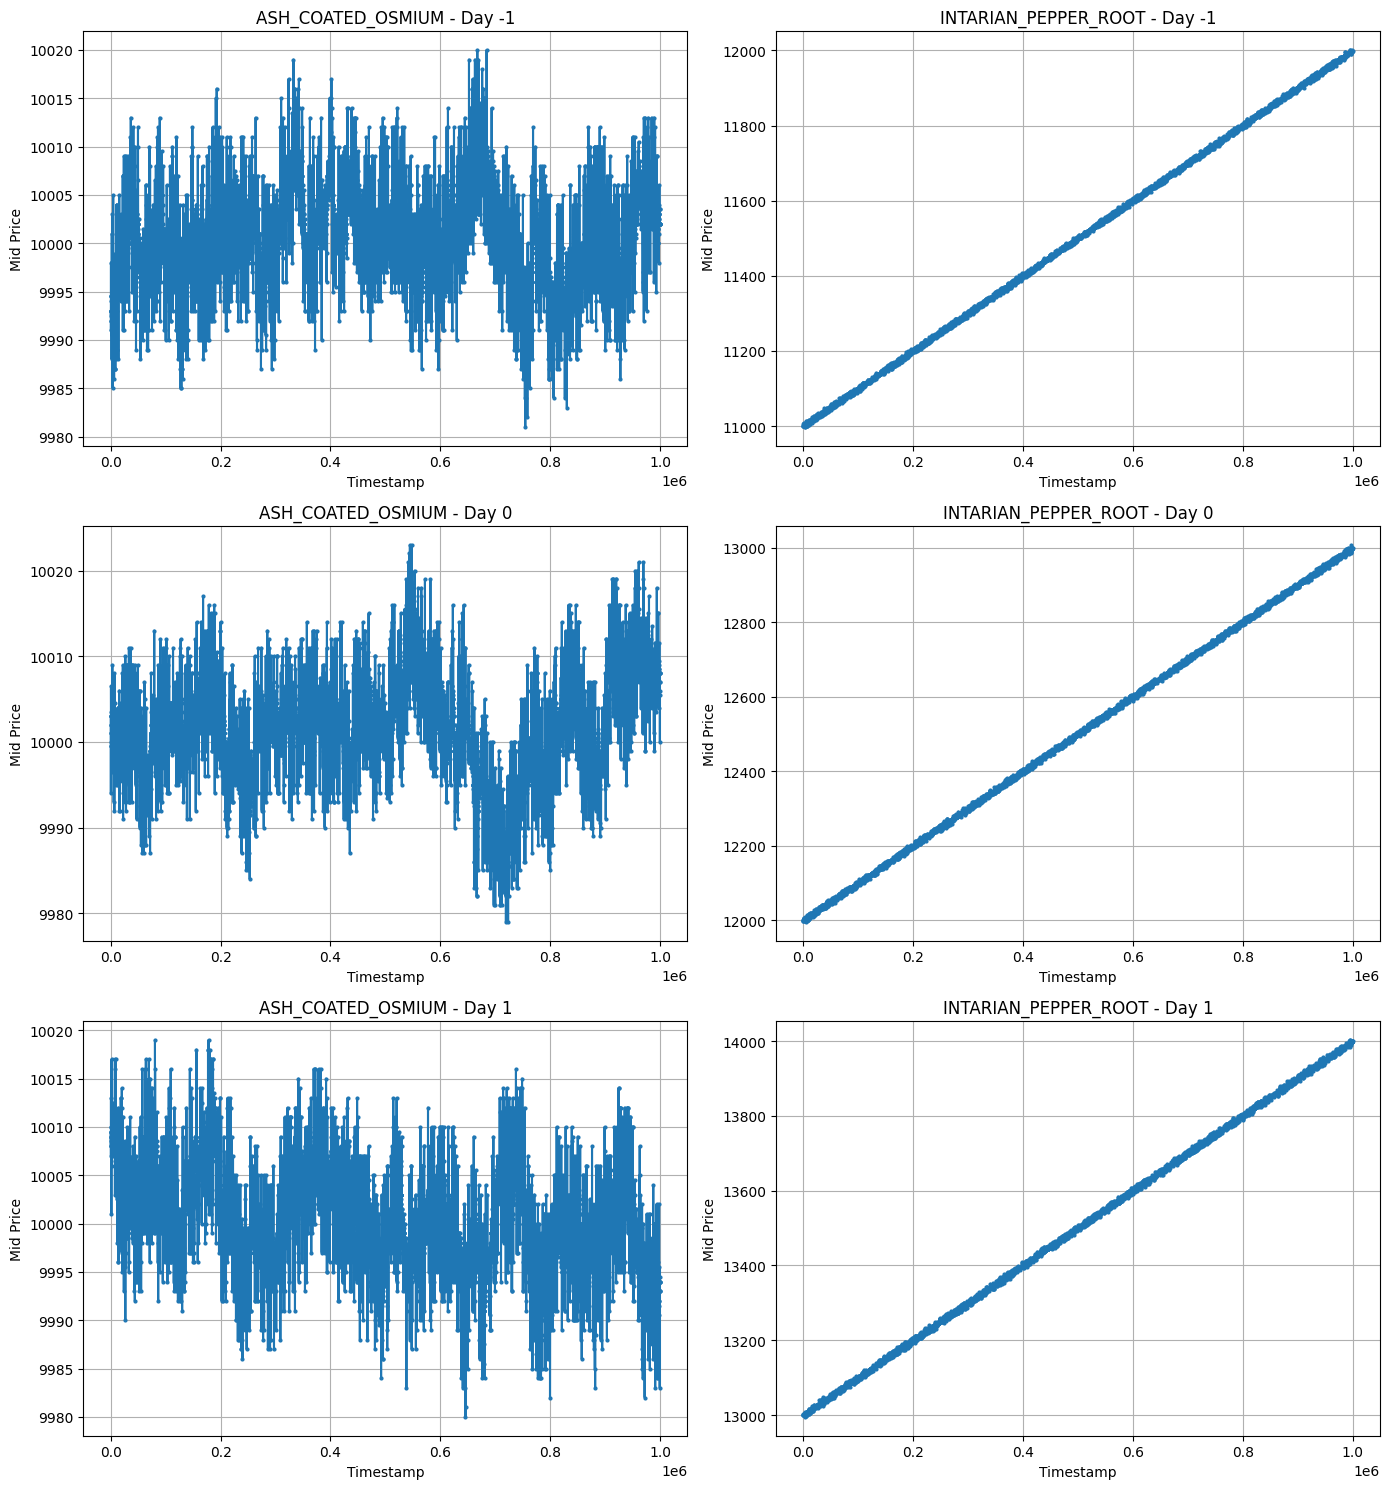

In [6]:
fig, axes = plt.subplots(len(files), 2, figsize=(14, 5 * len(files)))

products = ['ASH_COATED_OSMIUM', 'INTARIAN_PEPPER_ROOT']

for idx, file in enumerate(files):
    day = file.split('_day_')[1].replace('.csv', '')
    df = pd.read_csv(file, sep=';')
    
    for p_idx, product in enumerate(products):
        ax = axes[idx, p_idx] if len(files) > 1 else axes[p_idx]
        product_df = df[df['product'] == product]

        product_df = product_df[product_df['mid_price'] > np.int64(0)]

        ax.plot(product_df['timestamp'], product_df['mid_price'].dropna(), marker='o', markersize=2)
        ax.set_title(f"{product} - Day {day}")
        ax.set_xlabel('Timestamp')
        ax.set_ylabel('Mid Price')
        ax.grid(True)

plt.tight_layout()
plt.show()

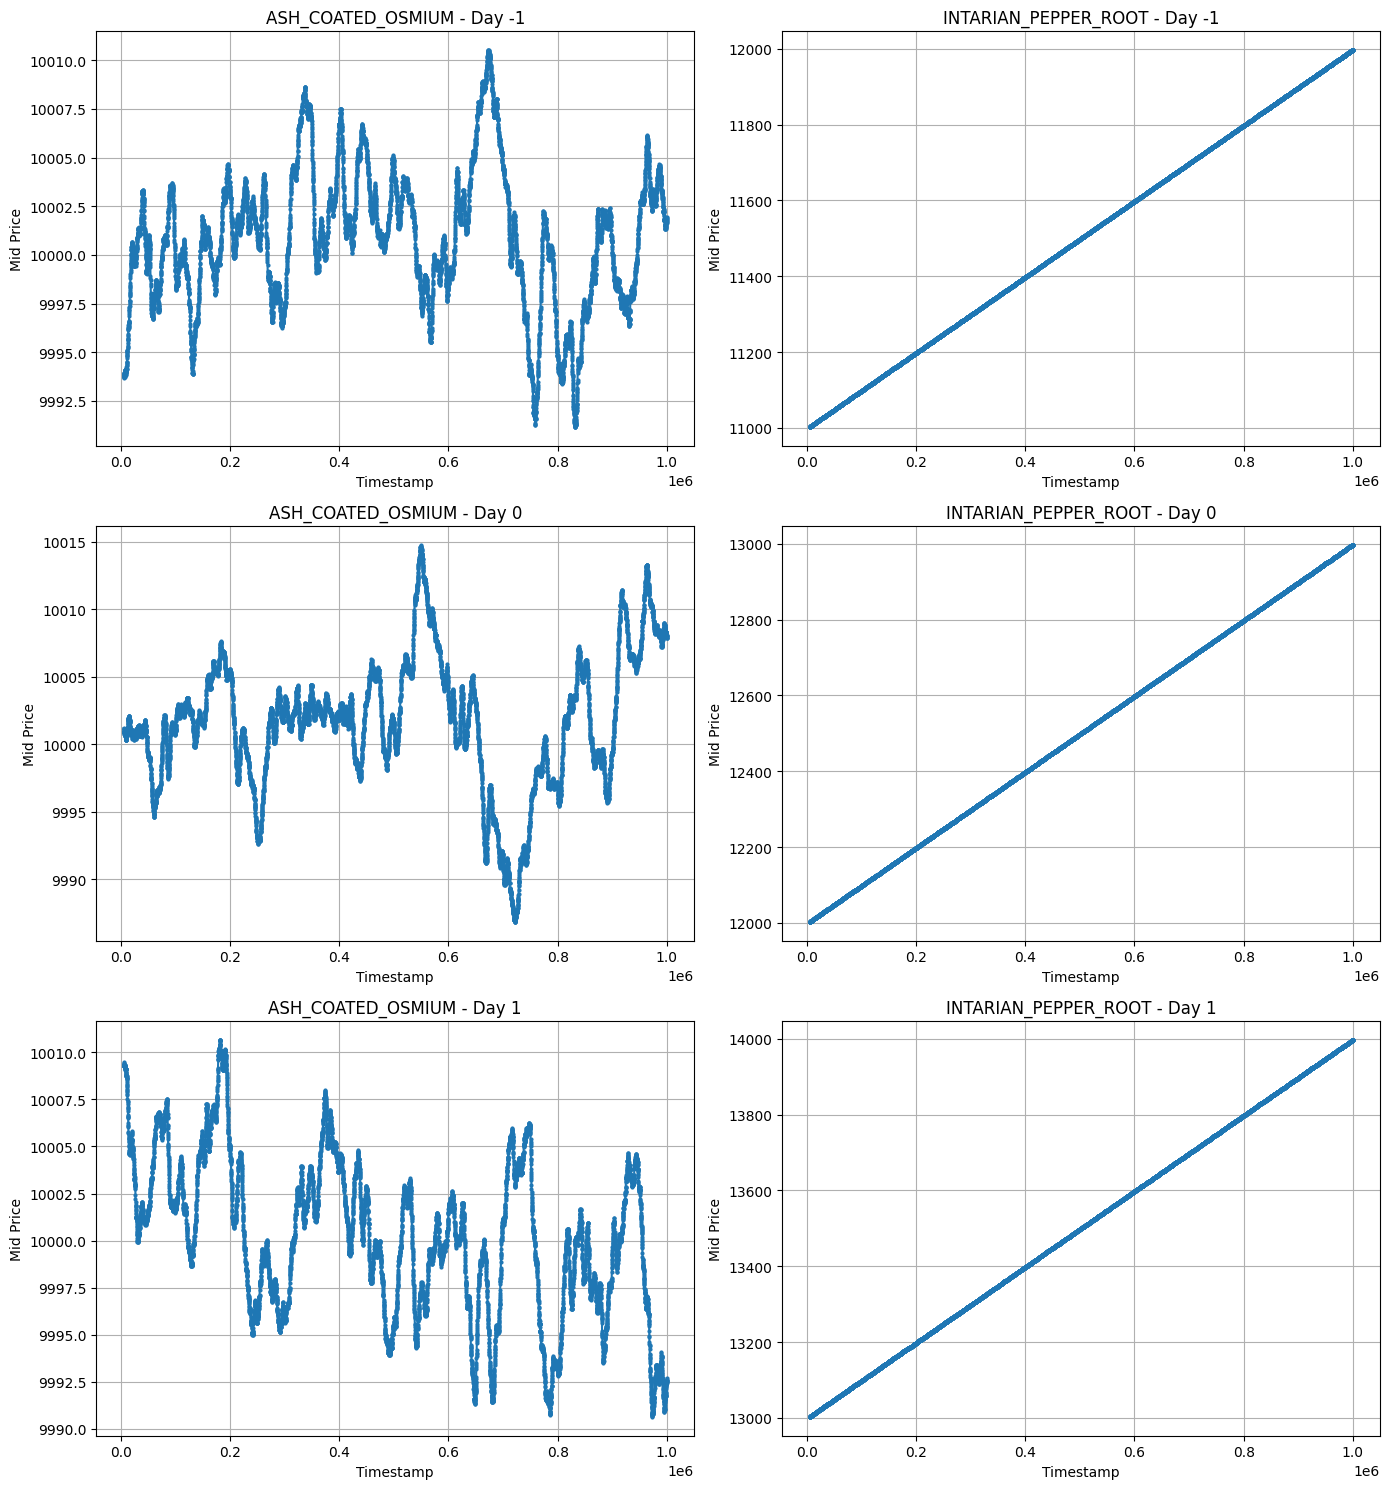

In [7]:
fig, axes = plt.subplots(len(files), 2, figsize=(14, 5 * len(files)))

products = ['ASH_COATED_OSMIUM', 'INTARIAN_PEPPER_ROOT']

for idx, file in enumerate(files):
    day = file.split('_day_')[1].replace('.csv', '')
    df = pd.read_csv(file, sep=';')
    
    for p_idx, product in enumerate(products):
        ax = axes[idx, p_idx] if len(files) > 1 else axes[p_idx]
        product_df = df[df['product'] == product]

        product_df = product_df[product_df['mid_price'] > np.int64(0)]
        product_df['rolling_mean'] = product_df['mid_price'].rolling(window=50).mean()

        ax.plot(product_df['timestamp'], product_df['rolling_mean'], marker='o', markersize=2)
        ax.set_title(f"{product} - Day {day}")
        ax.set_xlabel('Timestamp')
        ax.set_ylabel('Mid Price')
        ax.grid(True)

plt.tight_layout()
plt.show()

In [8]:
product_df.columns

Index(['day', 'timestamp', 'product', 'bid_price_1', 'bid_volume_1',
       'bid_price_2', 'bid_volume_2', 'bid_price_3', 'bid_volume_3',
       'ask_price_1', 'ask_volume_1', 'ask_price_2', 'ask_volume_2',
       'ask_price_3', 'ask_volume_3', 'mid_price', 'profit_and_loss',
       'rolling_mean'],
      dtype='object')

In [9]:
# Load all Round 2 files
round2_files = sorted(glob.glob('Round 2/prices_round_2_day*.csv'))
df_r2 = pd.concat([pd.read_csv(f, sep=';') for f in round2_files])
print(f"Loaded {len(round2_files)} files")

Loaded 3 files


In [11]:
# Extract data for each product
ash_df = df_r2[df_r2['product'] == 'ASH_COATED_OSMIUM'].sort_values('timestamp').copy()
intar_df = df_r2[df_r2['product'] == 'INTARIAN_PEPPER_ROOT'].sort_values('timestamp').copy()

In [13]:
ash_df = ash_df[ash_df['mid_price'] > np.int64(0)]
intar_df = intar_df[intar_df['mid_price'] > np.int64(0)]

# Calculate returns (percentage change in mid_price)
ash_df['returns'] = ash_df['mid_price'].pct_change()
intar_df['returns'] = intar_df['mid_price'].pct_change()

# Calculate rolling volatility (using 100-period window)
ash_df['volatility'] = ash_df['returns'].rolling(window=100).std() * np.sqrt(100)
intar_df['volatility'] = intar_df['returns'].rolling(window=100).std() * np.sqrt(100)

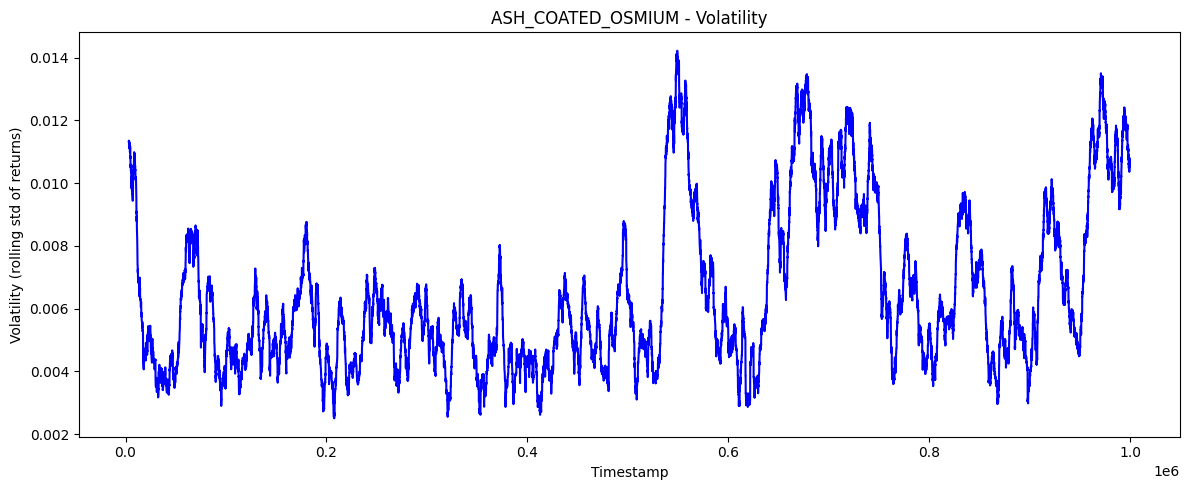

In [14]:
# Plot ASH_COATED_OSMIUM volatility
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(ash_df['timestamp'], ash_df['volatility'], color='blue')
ax.set_title('ASH_COATED_OSMIUM - Volatility')
ax.set_xlabel('Timestamp')
ax.set_ylabel('Volatility (rolling std of returns)')
plt.tight_layout()
plt.show()

Found files: ['Round 3\\prices_round_3_day_0.csv', 'Round 3\\prices_round_3_day_1.csv', 'Round 3\\prices_round_3_day_2.csv']


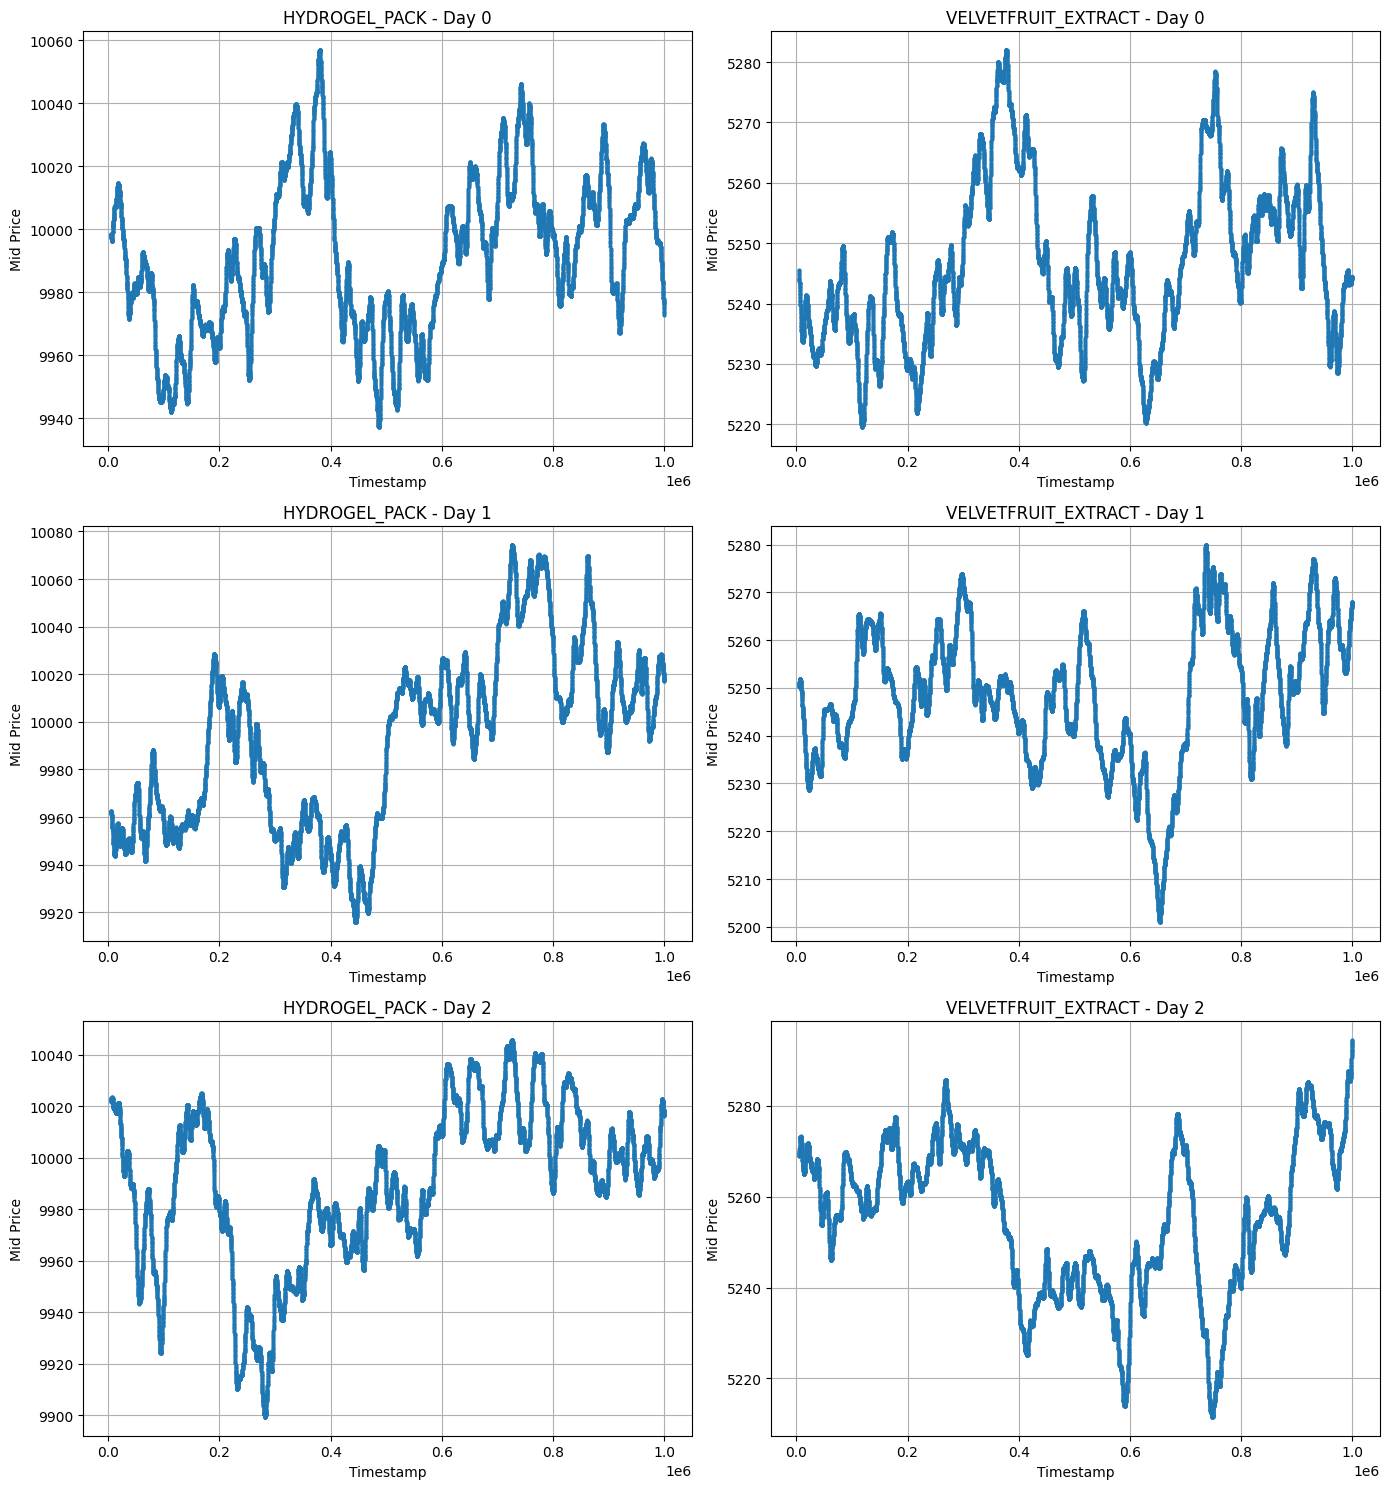

In [3]:
files = sorted(glob.glob('Round 3/prices_round_3_day_*.csv'))
print("Found files:", files)

fig, axes = plt.subplots(len(files), 2, figsize=(14, 5 * len(files)))

products = ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT']

for idx, file in enumerate(files):
    day = file.split('_day_')[1].replace('.csv', '')
    df = pd.read_csv(file, sep=';')
    
    for p_idx, product in enumerate(products):
        ax = axes[idx, p_idx] if len(files) > 1 else axes[p_idx]
        product_df = df[df['product'] == product]

        product_df = product_df[product_df['mid_price'] > np.int64(0)]
        product_df['rolling_mean'] = product_df['mid_price'].rolling(window=50).mean()

        ax.plot(product_df['timestamp'], product_df['rolling_mean'], marker='o', markersize=2)
        ax.set_title(f"{product} - Day {day}")
        ax.set_xlabel('Timestamp')
        ax.set_ylabel('Mid Price')
        ax.grid(True)

plt.tight_layout()
plt.show()

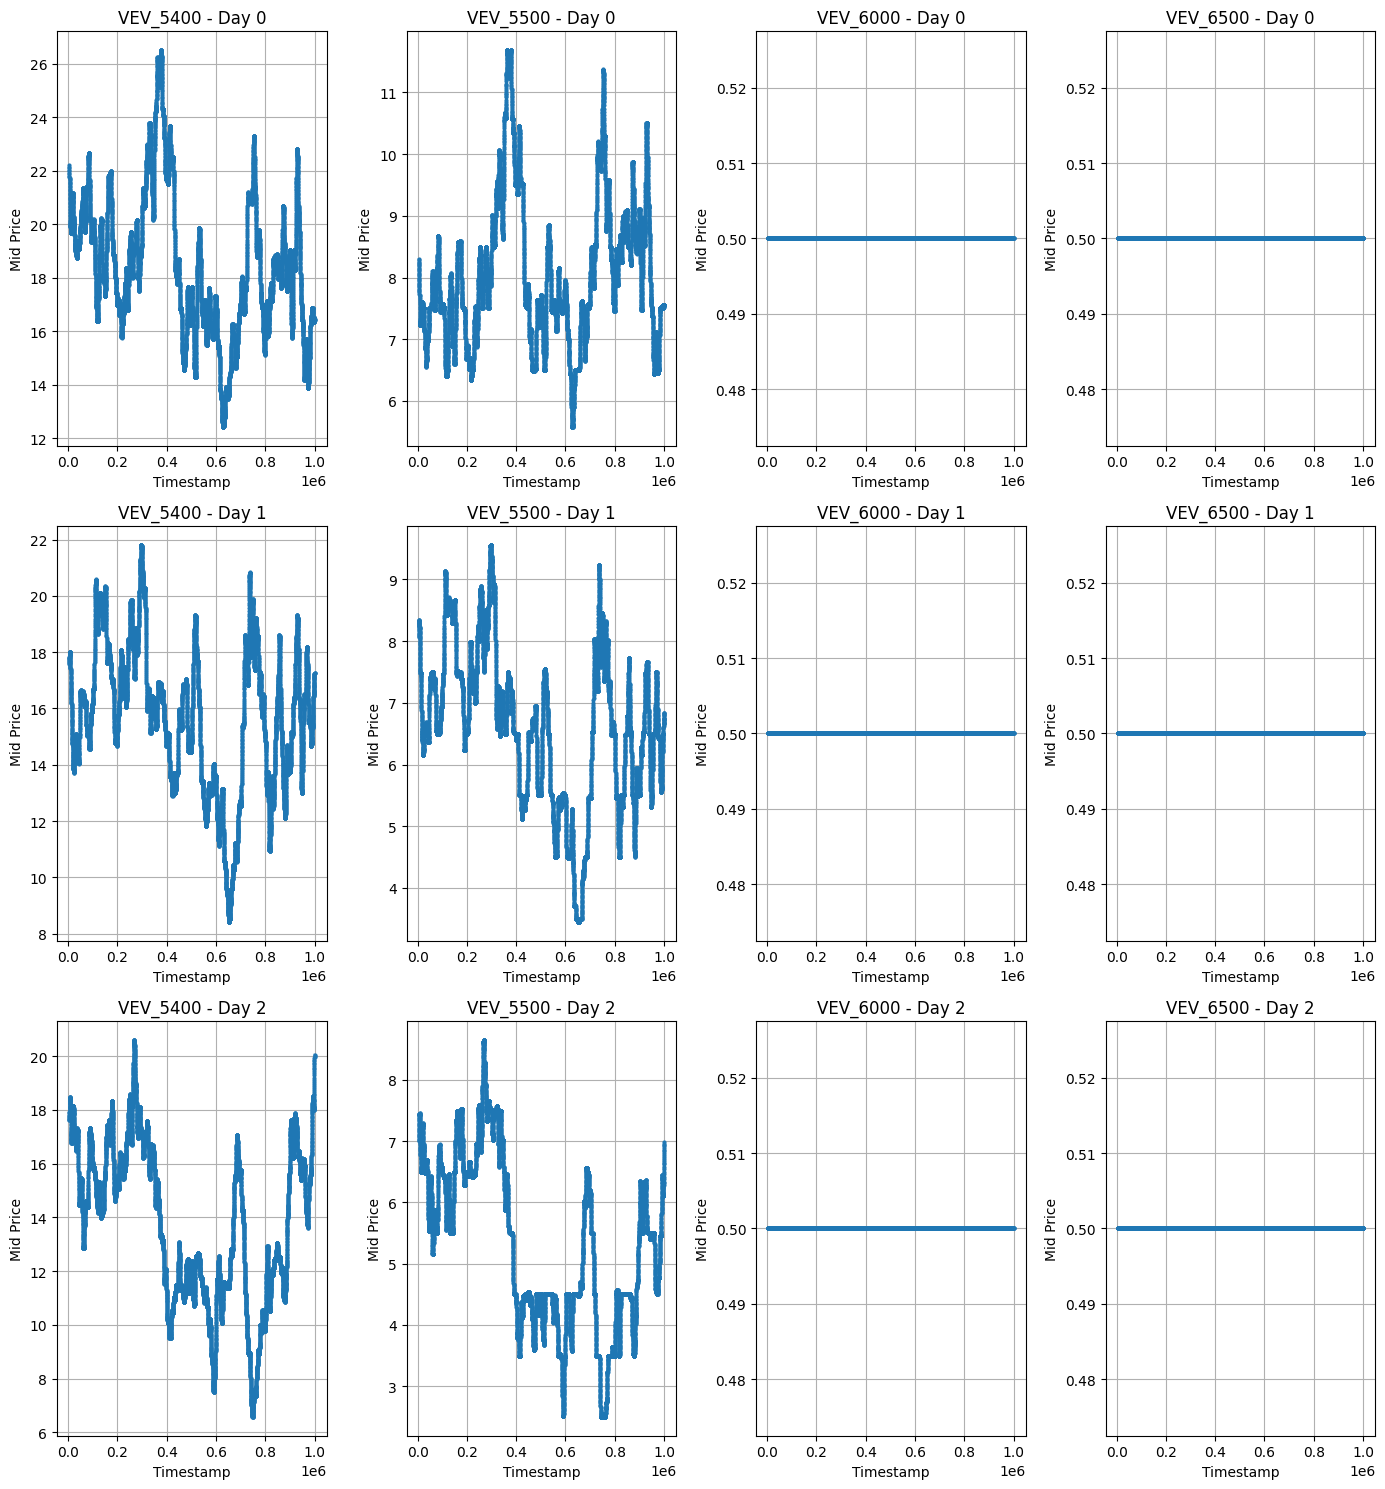

In [20]:
fig, axes = plt.subplots(len(files), 4, figsize=(14, 5 * len(files)))

#products = [product for venv in]

for idx, file in enumerate(files):
    day = file.split('_day_')[1].replace('.csv', '')
    df = pd.read_csv(file, sep=';')
    products = [product for product in df['product'].unique() if product.startswith("VEV_")]
    products.sort()
    products = products[6:]


    for p_idx, product in enumerate(products):
        ax = axes[idx, p_idx] if len(files) > 1 else axes[p_idx]
        product_df = df[df['product'] == product]

        product_df = product_df[product_df['mid_price'] > np.int64(0)]
        product_df['rolling_mean'] = product_df['mid_price'].rolling(window=50).mean()

        ax.plot(product_df['timestamp'], product_df['rolling_mean'], marker='o', markersize=2)
        ax.set_title(f"{product} - Day {day}")
        ax.set_xlabel('Timestamp')
        ax.set_ylabel('Mid Price')
        ax.grid(True)

plt.tight_layout()
plt.show()

In [30]:
testdf = pd.read_csv('Round 3/prices_round_3_day_0.csv', sep=";")

venv_products = [product for product in testdf['product'].unique() if product.startswith("VEV_")]
venv_products.sort()

product_stats = {
    "product": venv_products,
    "std": [],
    "mean": []
}

#for file in files:
#df = pd.read_csv(file, sep=';')
df = testdf

for product in venv_products:
    product_df = df[df['product'] == product]

    stdev = float(product_df['mid_price'].std())
    mean = float(product_df['mid_price'].mean())

    product_stats['std'].append(stdev)
    product_stats['mean'].append(mean)
        

zipped = zip(product_stats['product'], product_stats['std'], product_stats['mean'])
print("voucher | std | mean")
list(zipped)

voucher | std | mean


[('VEV_4000', 13.698110563625237, 1246.5241),
 ('VEV_4500', 13.686640049756006, 746.5216),
 ('VEV_5000', 12.488839291971294, 253.2595),
 ('VEV_5100', 10.954784408656522, 168.1077),
 ('VEV_5200', 8.165664149173642, 97.4709),
 ('VEV_5300', 5.179954337896645, 48.8925),
 ('VEV_5400', 2.7807239489147437, 18.46725),
 ('VEV_5500', 1.23689243177763, 8.05895),
 ('VEV_6000', 0.0, 0.5),
 ('VEV_6500', 0.0, 0.5)]

Found files: ['Round 4\\prices_round_4_day_0.csv', 'Round 4\\prices_round_4_day_1.csv', 'Round 4\\prices_round_4_day_2.csv', 'Round 4\\prices_round_4_day_3.csv']


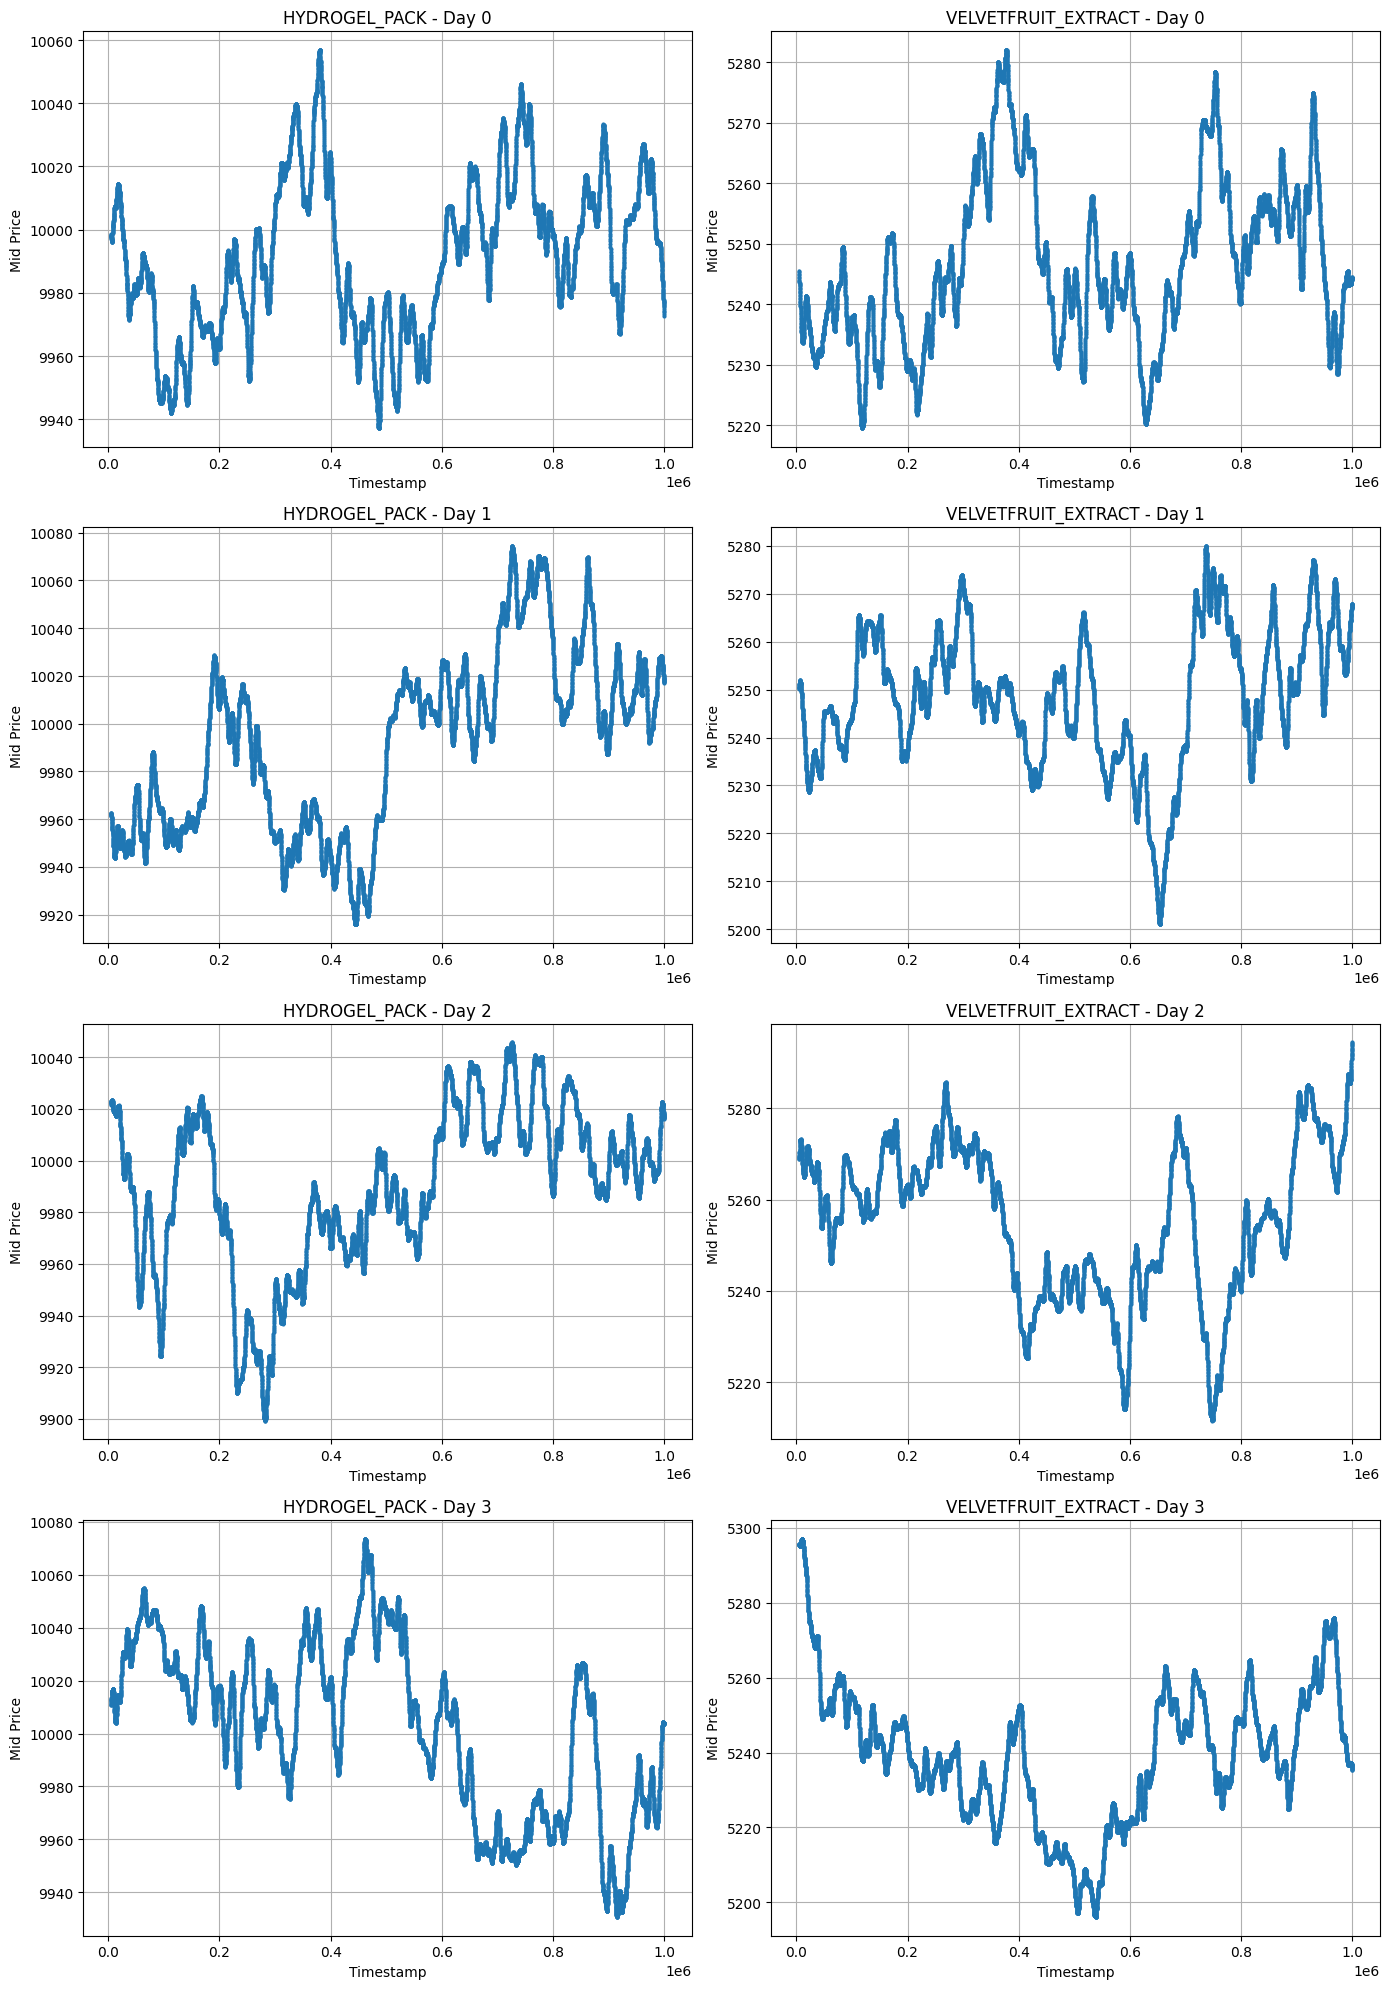

In [4]:
files = sorted(glob.glob('Round 4/prices_round_4_day_*.csv'))
print("Found files:", files)

fig, axes = plt.subplots(len(files), 2, figsize=(14, 5 * len(files)))

products = ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT']

for idx, file in enumerate(files):
    day = file.split('_day_')[1].replace('.csv', '')
    df = pd.read_csv(file, sep=';')
    
    for p_idx, product in enumerate(products):
        ax = axes[idx, p_idx] if len(files) > 1 else axes[p_idx]
        product_df = df[df['product'] == product]

        product_df = product_df[product_df['mid_price'] > np.int64(0)]
        product_df['rolling_mean'] = product_df['mid_price'].rolling(window=50).mean()

        ax.plot(product_df['timestamp'], product_df['rolling_mean'], marker='o', markersize=2)
        ax.set_title(f"{product} - Day {day}")
        ax.set_xlabel('Timestamp')
        ax.set_ylabel('Mid Price')
        ax.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
trade_file1 = pd.read_csv('Round 4/trades_round_4_day_1.csv', sep=';')
trade_file1
